## CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Fall 2025

# Homework 2: Graph Mining Fun Times (110 points + 10 BONUS)


- **110 points [7.5% of your final grade]**
- **Due Thursday, October 2 by 11:59pm**


***Goals of this homework:***

1. Learn how to ingest and clean a graph dataset
2. Explore, visualize, and characterize directed graphs
3. Apply core graph mining techniques (e.g., PageRank, centralities, community detection via Personalized PageRank).
4. Design and complete more advanced analyses.


***Submission instructions:***

You should post your notebook to Canvas (look for the homework 2 assignment there). Please name your submission **your-uin_hw1.ipynb**, so for example, my submission would be something like **555001234_hw2.ipynb**. Your notebook should be fully executed when you submit ... so run all the cells for us so we can see the output, then submit that.

***Late Days:***

As a reminder, you begin the semester with five late days. You may use as many as you like. There is no need to alert us to how many late days you are using. Just submit and we will make note of it. Also remember that once your late days are used up, homeworks will receive a 0.

***Collaboration and AI Assistance declaration:***

If you worked with someone on this homework, please be sure to mention that. Remember to include citations to any sources you use in the homework. Also tell us what AI assistant you used and how you used it.



## (REQUIRED) Collaboration and AI Assistance Declaration

### Collaboration Declaration:

none.

### AI Assistance Declaration:

I put each section into copilot by parts so I could see how each step was being done and view or tweak results. Most of these calculations for our outputs are already implemented in networkx, but I haven't used this package before so I'm glad copilot can make such quick work of collecting them.\
On the later (larger) sections I requested a full system, and tweaked display or approach as results showed more information about the data.

# Overview
In this homework, you will **choose one dataset you like** from the [SNAP datasets](https://snap.stanford.edu/data/index.html) collection from the **Social networks** section. You must choose a  **directed graph only**. In this homework, you will perform a step‑by‑step data mining & experimental analysis. *Much of this homework is self-directed, meaning you will need to make critical decisions about what tools you use and what you explore.*

Ideally, you should eventually turn in a coherent story: **What you tried → Why → What you found → So what? → Wait...Anything more?**. It's completely OKAY if you only get minor discoveries. But you should always document the whole learning and reasoning process. Grading will be based on the logic and coherence of your submitted notebook.


## 0. Environment Setup
You may use **Python 3.9+**. Other possible tools are:
- **Graph tools**: You are welcome to use existing tools that are optimised for graph learning. Among them, `networkx`is recommended. `graph-tool` and `igraph` are also good when dealing with larger graphs.
- **Data processing packages**: eg. `numpy`, `pandas`
- **Plotting**: `matplotlib`, `plotly`, `seaborn` etc.
- **other related tools** `scipy`, `scikit-learn`,  `pytorch` etc.
- You may choose other tools; just be sure to let us know.

> If your chosen dataset is very large, consider using `graph-tool` and `igraph`, or sampling/induced subgraphs to stay within time/memory limits.


In [20]:
# Install libraries as needed (uncomment if running on a clean environment)
# %pip install networkx pandas numpy matplotlib scipy scikit-learn
# %pip install python-louvain igraph

import os, io, gzip, zipfile, tarfile, sys, math, random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# For reproducibility
random.seed(42)
np.random.seed(42)

print(nx.__version__)

3.3


## 1. Choose a Dataset (5 pts)
Pick **one** dataset from SNAP's **Directed networks** (e.g.`ego-Twitter`, `wiki-Vote` samples, etc.). Paste the **download URL** and a brief description of why you chose it.

### **Dataset name:** 
higgs-reply_network
### **URL:** 
https://snap.stanford.edu/data/higgs-reply_network.edgelist.gz
### **Why this dataset?** 
The discovery of the Higgs Boson was really cool, it caught my eye while I was on the SNAP page. They had multiple collections of Twitter data about and around the discovery, I chose the reply set since it is a directed graph of communication about the boson with managable node and edge sizes.

> ⚠️ Make sure it's **directed**. ✅


In [21]:
# === You may using the follow method to download datasets if you like ===
DATA_URL = "https://snap.stanford.edu/data/higgs-reply_network.edgelist.gz"  # Example; replace with your chosen dataset
LOCAL_PATH = "data/higgs-reply_network.edgelist.gz"

os.makedirs("data", exist_ok=True)

def download_dataset(url: str, to_path: str):
    import urllib.request
    print(f"Downloading from {url} ...")
    urllib.request.urlretrieve(url, to_path)
    size = os.path.getsize(to_path) / (1024*1024)
    print(f"Saved to {to_path} ({size:.2f} MB)")

# Uncomment to download when ready
download_dataset(DATA_URL, LOCAL_PATH)
# I didnt run this, I downloaded it and manually placed it in the same directory

Saved to data/higgs-reply_network.edgelist.gz (0.19 MB)


## 2. Load & Parse the Directed Graph (5 pts)
First choose a graph tool and write a few lines of why you choose it and how you are going to use it. If you are not using any tools, please also document that.

> SNAP directed edge lists are usually in the form `src\t dst` per line, with comments starting with `#`.

Implement a robust loader that:
- Skips comment lines (if there is any)
- Builds a **`networkx.DiGraph`** (if you choose networkx)
- (Optional) Restricts to the **largest weakly connected component (WCC)** for clarity

Write your loading graph code here:

In [22]:
import gzip

def load_directed_graph(path, sep=None):
    """
    Loads a directed edge list from a gzipped file into a networkx.DiGraph.
    Skips comment lines starting with '#'.
    """
    G = nx.DiGraph()
    with gzip.open(path, 'rt') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.strip().split(sep) if sep else line.strip().split()
            if len(parts) >= 2:
                src, dst = parts[:2]
                G.add_edge(src, dst)
    return G

# Example usage:
# G = load_directed_graph("data/higgs-reply_network.edgelist.gz")
print(f"Loaded graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")

Loaded graph with 38918 nodes and 32523 edges.


This set seems pretty manageable, networkx should be enough to work on it.

In [92]:
edges = list(G.edges())
print(edges)

[('161345', '8614'), ('8614', '177615'), ('8614', '162765'), ('428368', '11792'), ('77904', '10701'), ('77904', '29353'), ('77904', '118086'), ('10701', '77904'), ('10701', '17165'), ('124554', '286277'), ('286277', '124554'), ('194873', '194873'), ('341375', '16460'), ('16460', '402886'), ('16460', '40773'), ('16460', '16453'), ('16460', '38176'), ('436133', '220'), ('274148', '274149'), ('274149', '274148'), ('12866', '22252'), ('12866', '25128'), ('12866', '9858'), ('425029', '35248'), ('126440', '39410'), ('39410', '16088'), ('39410', '22236'), ('39410', '19234'), ('39410', '677'), ('279630', '179783'), ('107949', '322'), ('387599', '456'), ('158380', '52504'), ('201087', '191708'), ('191708', '201087'), ('345941', '345940'), ('402405', '190354'), ('190354', '402405'), ('3228', '13537'), ('126681', '88'), ('27095', '8438'), ('8438', '23780'), ('245841', '88'), ('138795', '30798'), ('138795', '356'), ('318765', '3726'), ('3726', '115059'), ('3726', '19814'), ('424421', '88'), ('4915

## 3. First Look: Basic Structural Statistics (10 pts)
Compute and report at least:
- `|V|` (nodes), `|E|` (edges)
- **Average in/out degree**, **degree distributions** (plot)
- **#SCCs**, size of **largest SCC** and **largest WCC**
- *(Optional): **Density**, **reciprocity***

Add a few sentences interpreting what these numbers suggest about your network.


Nodes: 38918
Edges: 32523
Average in-degree: 0.84
Average out-degree: 0.84
Max in-degree: 1206.00
Max out-degree: 35.00


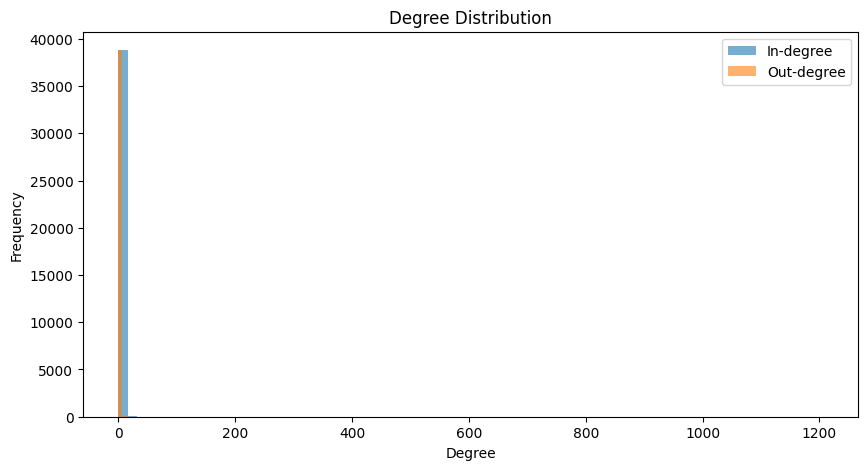

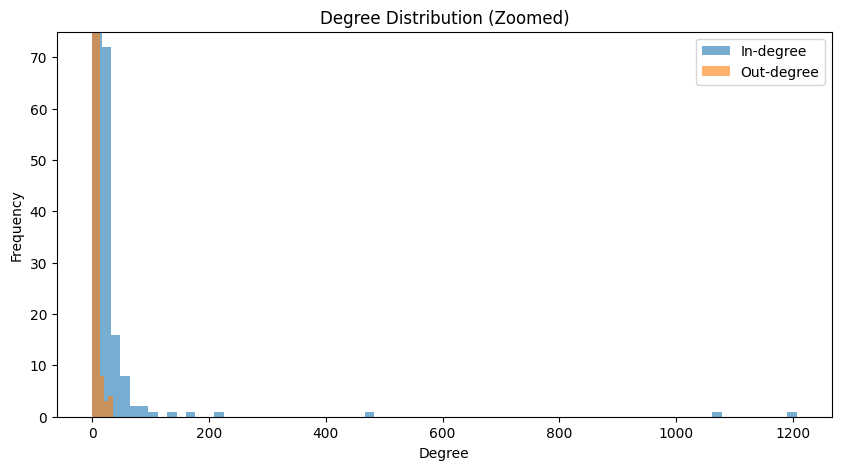

Number of SCCs: 36132
Largest SCC size: 322
Number of WCCs: 10641
Largest WCC size: 12839
Density: 0.000021
Reciprocity: 0.1616


In [23]:
def basic_stats(G: nx.DiGraph):
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    in_degrees = [d for n, d in G.in_degree()]
    out_degrees = [d for n, d in G.out_degree()]
    avg_in_deg = sum(in_degrees) / num_nodes
    avg_out_deg = sum(out_degrees) / num_nodes

    print(f"Nodes: {num_nodes}")
    print(f"Edges: {num_edges}")
    print(f"Average in-degree: {avg_in_deg:.2f}")
    print(f"Average out-degree: {avg_out_deg:.2f}")
    print(f"Max in-degree: {max(in_degrees):.2f}")
    print(f"Max out-degree: {max(out_degrees):.2f}")


    plt.figure(figsize=(10,5))
    plt.hist(in_degrees, bins=75, alpha=0.6, label='In-degree')
    plt.hist(out_degrees, bins=5, alpha=0.6, label='Out-degree')
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.title('Degree Distribution')
    plt.legend()
    plt.show()

    # Distribution with capped Y-axis
    plt.figure(figsize=(10,5))
    plt.hist(in_degrees, bins=75, alpha=0.6, label='In-degree')
    plt.hist(out_degrees, bins=5, alpha=0.6, label='Out-degree')
    plt.xlabel('Degree')
    plt.ylabel('Frequency')
    plt.title('Degree Distribution (Zoomed)')
    plt.ylim(0, 75)
    plt.legend()
    plt.show()

    # Strongly Connected Components (SCCs)
    sccs = list(nx.strongly_connected_components(G))
    num_sccs = len(sccs)
    largest_scc = max(sccs, key=len)
    print(f"Number of SCCs: {num_sccs}")
    print(f"Largest SCC size: {len(largest_scc)}")

    # Weakly Connected Components (WCCs)
    wccs = list(nx.weakly_connected_components(G))
    largest_wcc = max(wccs, key=len)
    print(f"Number of WCCs: {len(wccs)}")
    print(f"Largest WCC size: {len(largest_wcc)}")

    density = nx.density(G)
    reciprocity = nx.reciprocity(G)
    print(f"Density: {density:.6f}")
    print(f"Reciprocity: {reciprocity:.4f}")


basic_stats(G)

We see a fairly sparse graph, with ~2 highly in-connected nodes and all nodes have relatively few out-connections. Our most connected node (1200) is likely the announcement of the discovery of the Higgs Boson, with many users interested about the news responding. We see a second highly connected node (~1075) almost matching the first and several other outliers (~450,100-200), but most of our nodes have 100 or less in-connections.

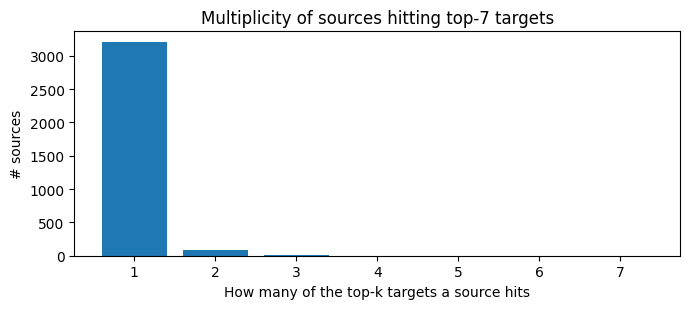

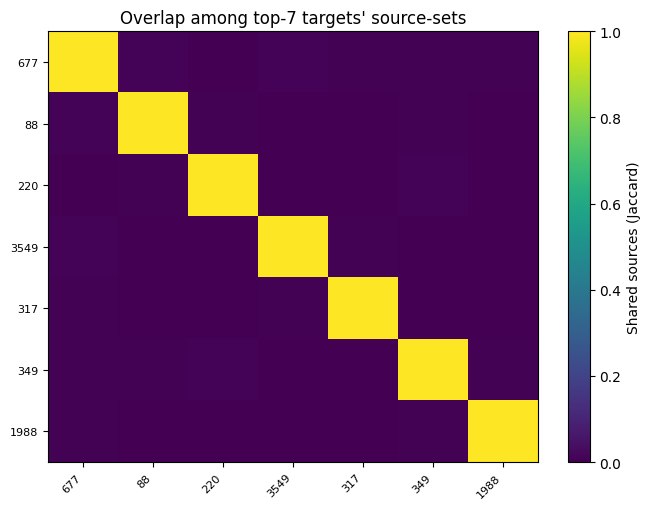

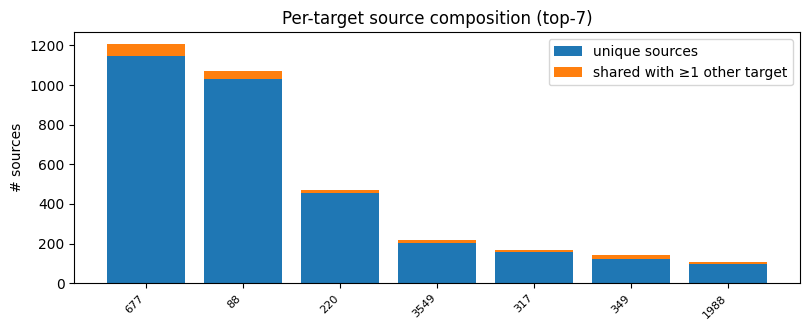

Top-7 targets: ['677', '88', '220', '3549', '317', '349', '1988']
Histogram m=1..7: {1: 3207, 2: 79, 3: 5, 4: 0, 5: 0, 6: 0, 7: 0}
677: total=1206  shared=60 (5.0%)  unique=1146
88: total=1071  shared=41 (3.8%)  unique=1030
220: total=470  shared=16 (3.4%)  unique=454
3549: total=218  shared=16 (7.3%)  unique=202
317: total=168  shared=10 (6.0%)  unique=158
349: total=142  shared=20 (14.1%)  unique=122
1988: total=105  shared=10 (9.5%)  unique=95


In [81]:
import networkx as nx
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt

def topk_in_neighbor_distribution(
    G: nx.DiGraph,
    k: int = 7,
    exclude_top_sources: bool = True,
    plot: bool = True,
    heatmap: str = "jaccard"  # "count" or "jaccard"
):
    """
    For the top-k nodes by in-degree:
      - Build targets_per_source: for each source node u, which of the top-k targets it points to
      - Build sources_per_target: for each top target t, set of sources that point to t
      - Histogram of multiplicity: how many sources hit exactly m of the top-k (m=1..k)
      - Per-target shared ratio: fraction of a target's sources that also hit >=1 other top target
      - Pairwise overlap (counts and Jaccard) between targets' source sets

    Parameters
    ----------
    exclude_top_sources : if True, discard sources that are themselves in the top-k set.

    Returns
    -------
    result : dict with keys:
      - 'topk': list[top targets]
      - 'sources_per_target': dict[target] -> set(sources)
      - 'targets_per_source': dict[source] -> set(targets among topk)
      - 'hist_multiplicity': dict[m] -> count of sources that hit exactly m targets
      - 'per_target_stats': dict[target] -> {'total','unique','shared','shared_ratio'}
      - 'pairwise_overlap_counts': dict[(ti,tj)] -> |Si ∩ Sj|
      - 'pairwise_overlap_jaccard': dict[(ti,tj)] -> |Si ∩ Sj| / |Si ∪ Sj|
    """
    assert isinstance(G, (nx.DiGraph, nx.MultiDiGraph))
    indeg = dict(G.in_degree())
    topk = sorted(indeg, key=indeg.get, reverse=True)[:k]
    topset = set(topk)

    # Build mappings
    sources_per_target = {t: set() for t in topk}
    targets_per_source = defaultdict(set)

    if isinstance(G, nx.MultiDiGraph):
        edges_iter = ((u, v) for u, v, _key in G.edges(keys=True))
    else:
        edges_iter = G.edges()

    for u, v in edges_iter:
        if v in topset:
            if exclude_top_sources and u in topset:
                continue
            sources_per_target[v].add(u)
            targets_per_source[u].add(v)

    # Histogram: how many of the topk does each source hit?
    multiplicities = Counter(len(tset) for tset in targets_per_source.values())
    hist = {m: multiplicities.get(m, 0) for m in range(1, k+1)}

    # Per-target shared stats
    per_target_stats = {}
    for t, S in sources_per_target.items():
        shared = {u for u in S if len(targets_per_source[u]) >= 2}
        uniq   = S - shared
        total = len(S)
        per_target_stats[t] = {
            "total": total,
            "unique": len(uniq),
            "shared": len(shared),
            "shared_ratio": (len(shared) / total) if total else 0.0
        }

    # Pairwise overlaps among top targets' source sets
    pair_counts = {}
    pair_jacc   = {}
    for i in range(k):
        for j in range(i, k):
            ti, tj = topk[i], topk[j]
            Si, Sj = sources_per_target[ti], sources_per_target[tj]
            inter = len(Si & Sj)
            uni   = len(Si | Sj) if (Si or Sj) else 1
            pair_counts[(ti, tj)] = pair_counts[(tj, ti)] = inter
            pair_jacc[(ti, tj)]   = pair_jacc[(tj, ti)]   = inter / uni

    result = {
        "topk": topk,
        "sources_per_target": sources_per_target,
        "targets_per_source": dict(targets_per_source),
        "hist_multiplicity": hist,
        "per_target_stats": per_target_stats,
        "pairwise_overlap_counts": pair_counts,
        "pairwise_overlap_jaccard": pair_jacc,
    }

    # Optional plots
    if plot:
        # 1) histogram of multiplicities
        xs = list(range(1, k+1))
        ys = [hist[m] for m in xs]
        plt.figure(figsize=(7, 3.2))
        plt.bar(xs, ys)
        plt.xticks(xs)
        plt.xlabel("How many of the top-k targets a source hits")
        plt.ylabel("# sources")
        plt.title(f"Multiplicity of sources hitting top-{k} targets")
        plt.tight_layout()
        plt.show()

        # 2) heatmap of pairwise overlap (counts or Jaccard)
        labels = topk
        M = np.zeros((k, k), dtype=float)
        if heatmap == "count":
            for i, ti in enumerate(labels):
                for j, tj in enumerate(labels):
                    M[i, j] = pair_counts[(ti, tj)]
            cbar_label = "Shared sources (count)"
        else:
            for i, ti in enumerate(labels):
                for j, tj in enumerate(labels):
                    M[i, j] = pair_jacc[(ti, tj)]
            cbar_label = "Shared sources (Jaccard)"

        fig, ax = plt.subplots(figsize=(6.8, 5.2))
        im = ax.imshow(M, aspect="auto")
        ax.set_xticks(range(k), labels=labels, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(k), labels=labels, fontsize=8)
        fig.colorbar(im, ax=ax, label=cbar_label)
        ax.set_title(f"Overlap among top-{k} targets' source-sets")
        plt.tight_layout()
        plt.show()

        # 3) per-target shared vs unique (stacked bar)
        t_labels = labels
        uniques = [per_target_stats[t]["unique"] for t in t_labels]
        shareds = [per_target_stats[t]["shared"] for t in t_labels]
        x = np.arange(len(t_labels))
        plt.figure(figsize=(8.2, 3.4))
        p1 = plt.bar(x, uniques, label="unique sources")
        p2 = plt.bar(x, shareds, bottom=uniques, label="shared with ≥1 other target")
        plt.xticks(x, t_labels, rotation=45, ha="right", fontsize=8)
        plt.ylabel("# sources")
        plt.title(f"Per-target source composition (top-{k})")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return result

res = topk_in_neighbor_distribution(G, k=7, exclude_top_sources=True, plot=True, heatmap="jaccard")

# Quick text summary:
print("Top-7 targets:", res["topk"])
print("Histogram m=1..7:", res["hist_multiplicity"])
for t, s in res["per_target_stats"].items():
    print(f"{t}: total={s['total']}  shared={s['shared']} ({s['shared_ratio']:.1%})  unique={s['unique']}")


Upon review (section 9) I realized I didn't know what the outliers were doing and I worked with the assumption that many users that replied to one had also replied to the others. I asked GPT to show this distribution by checking just 1-deep connections and found that this was not the case. Users that directly replied to one of our larger in-connected nodes seem to rarely reply to another. We could check 2-depth and 3-depth, but this is already further evidence of a sparce graph, though not as centered on the main node as initially thought.

## 4. Quick Visualization (Exploratory) (10 pts)
Produce a small subgraph visualization to build intuition (e.g., induced subgraph of top-`k` PageRank nodes or a random 500-node sample). For large graphs, you **don't have to** try to plot everything.

- Annotate what you observe (hubs? communities? sources/sinks?)


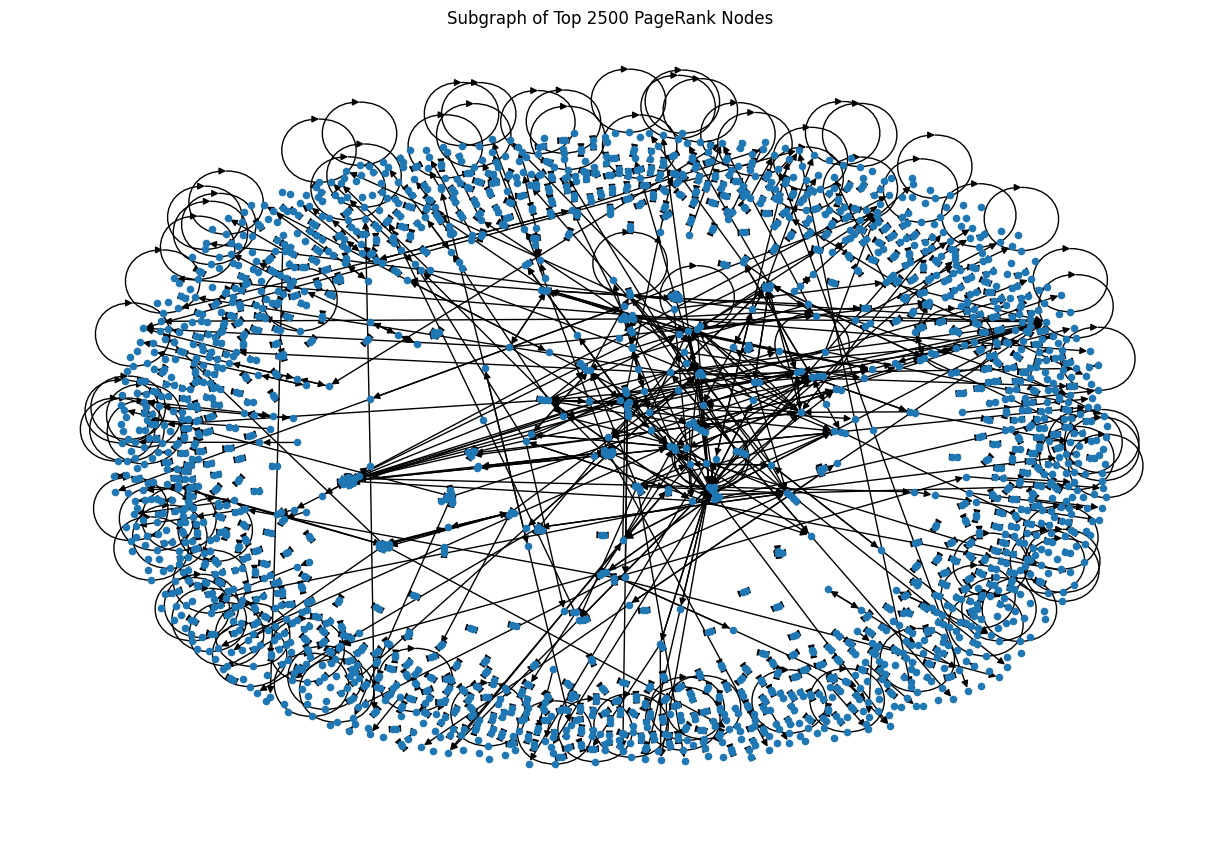

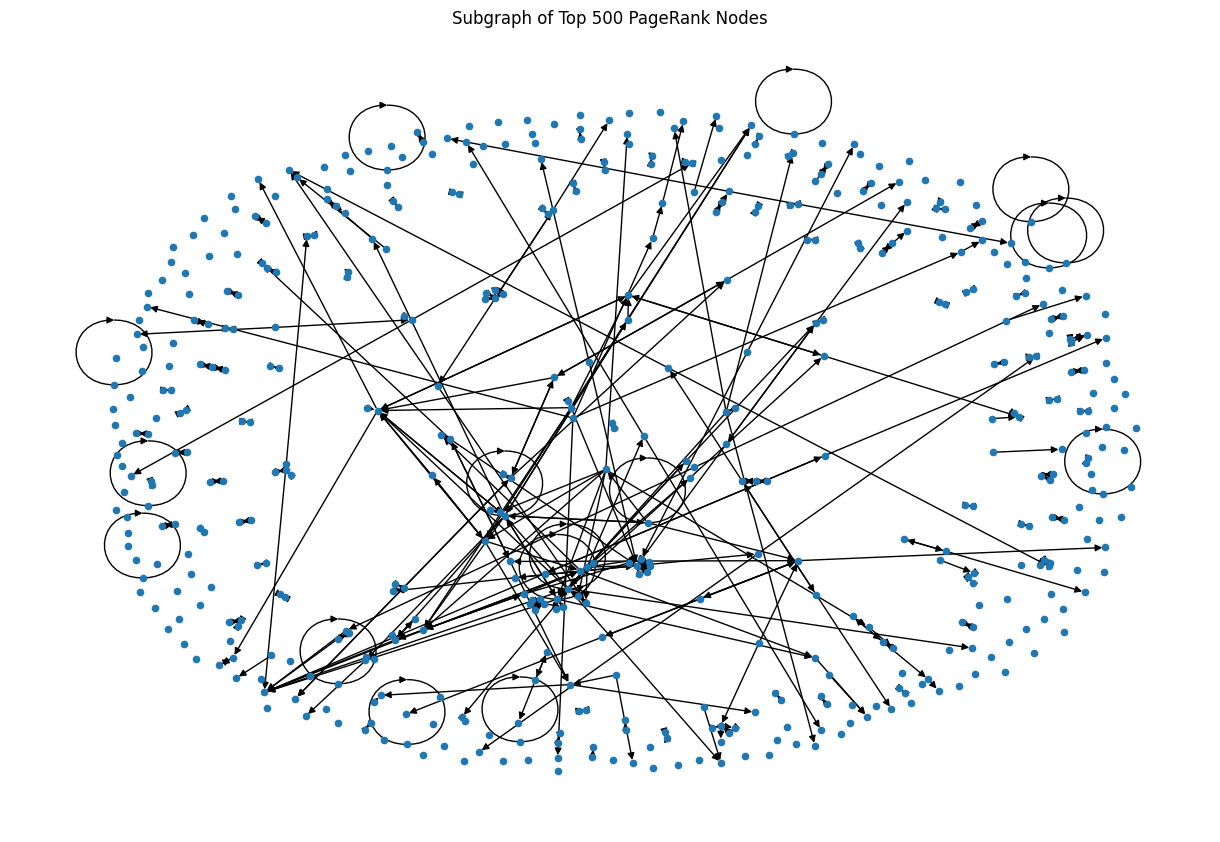

In [31]:
def visualize_subgraph_pagerank(G, k=1000):
    # Compute PageRank scores
    pr = nx.pagerank(G)
    # Get top-k nodes by PageRank
    top_nodes = sorted(pr, key=pr.get, reverse=True)[:min(k, G.number_of_nodes())]
    subG = G.subgraph(top_nodes)
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(subG, seed=42)
    nx.draw(subG, pos, node_size=20, arrowsize=10, with_labels=False)
    plt.title(f"Subgraph of Top {len(top_nodes)} PageRank Nodes")
    plt.show()

# Example usage:
visualize_subgraph_pagerank(G, k=2500)
visualize_subgraph_pagerank(G, k=500)

We see many of our highly connected nodes towards the center, finding their connections around the sample. We see many pairs (and sometimes triads or more) of nodes that connect to eachother, this shows accounts that have replied to eachother. Some of our nodes have rings to show when they have replied to themselves. We also see many nodes without any connections within their sample.

In our 2500 sample we see several smaller clusters connected to one another spread across the center of the sample. Many of our high pageranked nodes that replied to themselves didn't reply or get replied to by other high pageranked nodes, this could be for various reasons but generally means that these are accounts that smaller accounts respond to rather than reaching out, or possibly increased their score by looping to themselves.

## 5. Centrality Analyses (25 pts)
First, you must compute
- **PageRank**
as a baseline centrality measure.

Then you should choose at least one of the following to compare with:

- **HITS** (hubs/authorities)
- **In-degree** and **out-degree** centrality (as baselines)
- **Katz** or **eigenvector** centrality on a symmetrized version

Create a small table of **top-20 nodes** by each measure and comment on overlaps/differences.


In [33]:
def print_top20_centralities(G):
    # PageRank
    pr = nx.pagerank(G)
    pr_top = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:20]
    print("Top 20 PageRank nodes:")
    for n, v in pr_top:
        print(f"{n}: {v:.5f}")
    print("\n")

    # HITS
    hubs, authorities = nx.hits(G)
    hits_hub_top = sorted(hubs.items(), key=lambda x: x[1], reverse=True)[:20]
    hits_auth_top = sorted(authorities.items(), key=lambda x: x[1], reverse=True)[:20]
    print("Top 20 HITS Hub nodes:")
    for n, v in hits_hub_top:
        print(f"{n}: {v:.5f}")
    print("\n")
    print("Top 20 HITS Authority nodes:")
    for n, v in hits_auth_top:
        print(f"{n}: {v:.5f}")
    print("\n")

    # In-degree
    in_deg = dict(G.in_degree())
    in_deg_top = sorted(in_deg.items(), key=lambda x: x[1], reverse=True)[:20]
    print("Top 20 In-degree nodes:")
    for n, v in in_deg_top:
        print(f"{n}: {v}")
    print("\n")

    # Out-degree
    out_deg = dict(G.out_degree())
    out_deg_top = sorted(out_deg.items(), key=lambda x: x[1], reverse=True)[:20]
    print("Top 20 Out-degree nodes:")
    for n, v in out_deg_top:
        print(f"{n}: {v}")
    print("\n")

    # Eigenvector centrality (may fail if graph is not strongly connected)
    try:
        eig = nx.eigenvector_centrality(G)
        eig_top = sorted(eig.items(), key=lambda x: x[1], reverse=True)[:20]
        print("Top 20 Eigenvector centrality nodes:")
        for n, v in eig_top:
            print(f"{n}: {v:.5f}")
        print("\n")
    except Exception as e:
        print("Eigenvector centrality could not be computed.\n")

    # Find nodes appearing in multiple top-20 lists
    sets = [
        set(n for n, _ in pr_top),
        set(n for n, _ in hits_hub_top),
        set(n for n, _ in hits_auth_top),
        set(n for n, _ in in_deg_top),
        set(n for n, _ in out_deg_top),
        set(n for n, _ in eig_top) if 'eig_top' in locals() else set()
    ]
    from collections import Counter
    all_nodes = [n for s in sets for n in s]
    multi_counts = Counter(all_nodes)
    multi_nodes = [n for n, c in multi_counts.items() if c > 1]
    print("Nodes appearing in multiple top-20 lists:")
    for n in multi_nodes:
        print(f"{n} (appears in {multi_counts[n]} lists)")

# Example usage:
print_top20_centralities(G)

Top 20 PageRank nodes:
677: 0.02347
88: 0.01010
220: 0.00437
10867: 0.00329
207364: 0.00329
152385: 0.00329
237807: 0.00329
118091: 0.00329
225859: 0.00329
201222: 0.00329
10844: 0.00269
10836: 0.00217
8005: 0.00196
3549: 0.00194
42177: 0.00176
7690: 0.00174
317: 0.00155
4368: 0.00150
137364: 0.00145
349: 0.00126


Top 20 HITS Hub nodes:
27311: 0.00085
76803: 0.00084
96775: 0.00084
103986: 0.00084
184519: 0.00084
110149: 0.00084
152755: 0.00084
163525: 0.00084
422718: 0.00084
14755: 0.00084
191347: 0.00084
443234: 0.00083
154627: 0.00083
448426: 0.00083
446017: 0.00083
323534: 0.00083
413300: 0.00083
91837: 0.00083
273882: 0.00083
209938: 0.00083


Top 20 HITS Authority nodes:
677: 0.62451
88: 0.10882
3549: 0.00897
2177: 0.00849
349: 0.00536
220: 0.00517
4368: 0.00457
317: 0.00393
1988: 0.00380
3998: 0.00248
9964: 0.00226
13808: 0.00192
553: 0.00181
511: 0.00173
4259: 0.00172
26092: 0.00166
4375: 0.00165
4526: 0.00161
9704: 0.00158
8209: 0.00158


Top 20 In-degree nodes:
677: 1206
88: 

Nodes appearing in multiple top-20 lists:\
88 : 2nd pagerank, 2nd HITS authority, 2nd in-degree\
677 : 1st pagerank, 1st HITS authority, 1st in-degree\
349 : pagerank, HITS authority, in-degree\
317 : pagerank, HITS authority, in-degree\
4368 : pagerank, HITS authority, in-degree\
3549 : pagerank, HITS authority, in-degree\
220 : 3rd pagerank, HITS authority, 3rd in-degree\
7690 : pagerank, in-degree\
27311 : HITS hub, out-degree\
4259 : HITS authority, in-degree\
1988 : HITS authority, in-degree\
3998 : HITS authority, in-degree\
2177 : HITS authority, in-degree\
8855 : out-degree, eigenvector centrality\
9021 : out-degree, eigenvector centrality\
33833 : out-degree, eigenvector centrality\
\
Pagerank, HITS authority,and in-degree are fairly correlated displayed in their highest scoring terms\
Out-degree and eigenvector centrality are somewhat related but much less directly, which makes sense because EC is scored by connections to higher scoring nodes. Quality connections over quantity\
More on HITS in section 8B

## 6. Connectivity Structure (10 pts)
- Count SCCs and WCCs; inspect the **giant SCC**.

- Pick 1–3 **representative SCCs** (by size) and compute internal stats (e.g., degree, density, average path length if feasible).

- Discuss what you observe about the structure of this subgraph.


In [34]:
def display_scc_wcc_stats(G):
    # Strongly Connected Components (SCCs)
    sccs = list(nx.strongly_connected_components(G))
    print(f"Number of SCCs: {len(sccs)}")
    print("Top 5 SCCs by size:")
    top_sccs = sorted(sccs, key=len, reverse=True)[:5]
    for i, comp in enumerate(top_sccs, 1):
        print(f"SCC {i}: Size = {len(comp)}, Nodes = {list(comp)[:10]}{'...' if len(comp) > 10 else ''}")

    # Weakly Connected Components (WCCs)
    wccs = list(nx.weakly_connected_components(G))
    print(f"\nNumber of WCCs: {len(wccs)}")
    print(f"Largest WCC size: {len(max(wccs, key=len))}")

# Example usage:
display_scc_wcc_stats(G)

Number of SCCs: 36132
Top 5 SCCs by size:
SCC 1: Size = 322, Nodes = ['4407', '253608', '10817', '199389', '237807', '17155', '52926', '52300', '25006', '52904']...
SCC 2: Size = 13, Nodes = ['11844', '235', '26677', '129450', '216258', '49673', '126272', '305859', '113367', '105276']...
SCC 3: Size = 10, Nodes = ['245376', '20152', '156668', '38602', '68633', '88392', '104193', '201976', '44119', '46750']
SCC 4: Size = 9, Nodes = ['14588', '50305', '120719', '77555', '8835', '27705', '120725', '57105', '49154']
SCC 5: Size = 8, Nodes = ['12824', '52277', '12887', '54706', '25248', '389', '11355', '7114']

Number of WCCs: 10641
Largest WCC size: 12839


In [37]:
def scc_internal_stats(G, top_n=3):
    sccs = list(nx.strongly_connected_components(G))
    top_sccs = sorted(sccs, key=len, reverse=True)[:top_n]
    for i, nodes in enumerate(top_sccs, 1):
        subG = G.subgraph(nodes).copy()
        degrees = [d for n, d in subG.degree()]
        avg_deg = sum(degrees) / len(degrees)
        density = nx.density(subG)
        try:
            avg_path_len = nx.average_shortest_path_length(subG)
        except Exception:
            avg_path_len = "N/A (not connected or too small)"
        print(f"SCC {i}:")
        print(f"  Size: {len(subG)}")
        print(f"  Avg degree: {avg_deg:.2f}")
        print(f"  Density: {density:.6f}")
        print(f"  Avg path length: {avg_path_len}")
        print("")

# Example usage:
scc_internal_stats(G, top_n=3)

SCC 1:
  Size: 322
  Avg degree: 4.40
  Density: 0.006850
  Avg path length: 8.420164083512317

SCC 2:
  Size: 13
  Avg degree: 3.85
  Density: 0.160256
  Avg path length: 2.7435897435897436

SCC 3:
  Size: 10
  Avg degree: 3.60
  Density: 0.200000
  Avg path length: 2.411111111111111



We have one large strongly connected component and many very small SCCs\
SCC path length decreases with size while density increases\
This makes sense based on what we saw in section 4, a large web of clusters and several tiny groups

## 7. Local Community via Personalized PageRank (PPR) (25 pts)
Pick a **seed node** (e.g., top PageRank, or a node of interest). Compute **personalized PageRank** with a restart vector focused on that node (or a small seed set).

- Extract a **local community** by thresholding PPR scores (e.g., top-`k` or score ≥ τ).
- Visualize the induced subgraph and **describe** the community's characteristics.
- Compare with a baseline (e.g., ego‑net, or Louvain on a symmetrized graph).

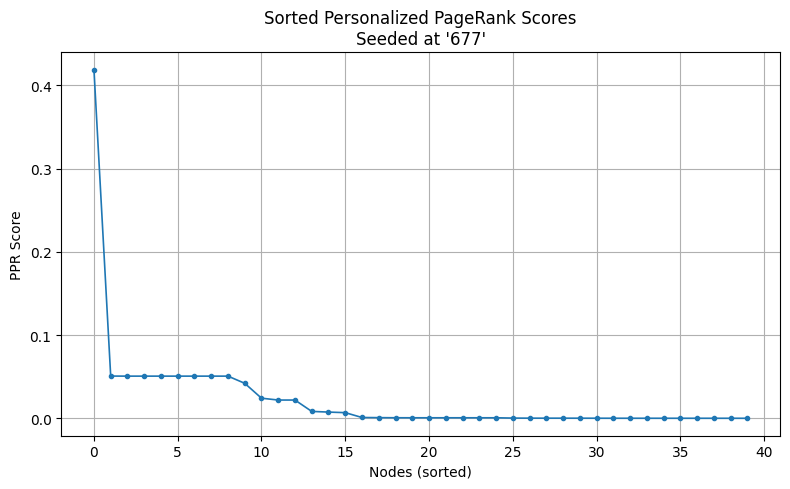

In [87]:

def plot_ppr_scores(ppr: dict, seed=None, ax=None):
    """
    Plot sorted Personalized PageRank scores to visualize score decay and possible community separation.
    """
    sorted_scores = sorted(ppr.values(), reverse=True)
    indices = range(len(sorted_scores))

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(indices[:40], sorted_scores[:40], marker='o', markersize=3, linewidth=1.2)
    ax.set_xlabel("Nodes (sorted)")
    ax.set_ylabel("PPR Score")
    ax.set_title(f"Sorted Personalized PageRank Scores" + (f"\nSeeded at '{seed}'" if seed else ""))
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# 1. Find most in-connected node
seed_node = max(G.in_degree, key=lambda x: x[1])[0]

# 2. Build one-hot personalization vector
personalization = {n: 0 for n in G}
personalization[seed_node] = 1.0

# 3. Compute personalized PageRank
ppr = nx.pagerank(G, alpha=0.85, personalization=personalization)
plot_ppr_scores(ppr, seed=seed_node)


Starting PPR at node 677, this node has the highest in-connections and the highest PR score. We see roughly 2~3 groups of scoring nodes\
I initially set alpha to .95 to attempt to reach further from the seed node, but the last 6 nodes of this graph are better represented at a=.85, and at .95 2 nodes were looping increasing their scores.

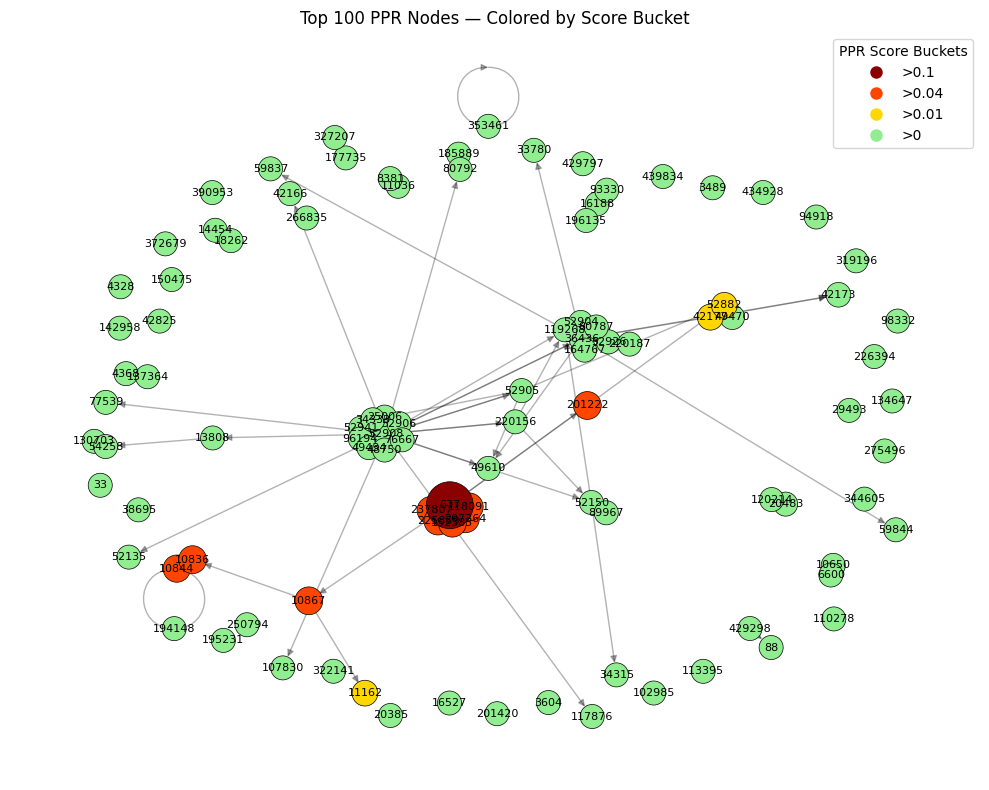

In [91]:
import matplotlib.colors as mcolors

def plot_top_ppr_clustered_graph(G: nx.DiGraph, ppr: dict, top_n: int = 40):
    """Plot one induced subgraph of top-N PPR nodes, colored by score bucket."""
    # Step 1: Sort & select top-N
    sorted_nodes = sorted(ppr.items(), key=lambda x: x[1], reverse=True)[:top_n]
    top_nodes = [node for node, _ in sorted_nodes]

    # Step 2: Induced subgraph
    subG = G.subgraph(top_nodes).copy()

    # Step 3: Bucket colors
    color_map = {
        '>0.1': 'darkred',
        '>0.04': 'orangered',
        '>0.01': 'gold',
        '>0': 'lightgreen',
    }

    def get_bucket(score):
        if score > 0.1:
            return '>0.1'
        elif score > 0.04:
            return '>0.04'
        elif score > 0.01:
            return '>0.01'
        else:
            return '>0'

    node_colors = [color_map[get_bucket(ppr[n])] for n in subG.nodes()]
    
    # Optional: node sizes proportional to PPR score
    node_sizes = [300 + 2000 * ppr[n] for n in subG.nodes()]

    # Step 4: Draw the graph
    pos = nx.spring_layout(subG, seed=42)
    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw_networkx_edges(subG, pos, alpha=0.3, arrows=True, ax=ax)
    nx.draw_networkx_nodes(
        subG, pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors='black',
        linewidths=0.5,
        ax=ax
    )
    nx.draw_networkx_labels(subG, pos, font_size=8, ax=ax)

    # Step 5: Custom legend
    handles = [plt.Line2D([0], [0], marker='o', color='w',
                          label=label,
                          markerfacecolor=color,
                          markersize=10)
               for label, color in color_map.items()]
    ax.legend(handles=handles, title='PPR Score Buckets')
    ax.set_title(f"Top {top_n} PPR Nodes — Colored by Score Bucket")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

plot_top_ppr_clustered_graph(G, ppr, top_n=100)


We see several connected nodes near our seed node, branching from this we have a high scoring cluster likely containing a loop (10844,10836). We see 2 medium scoring clusters (36436,52882) one of which is quite large (36436), and a lower ranking cluster (52908)\
Looking at our 100 highest scores we see multiple clusters start to form, from around 50~60 on display you will see the green clusters start to form, but not their connections to the seed node.

## 8. Choose‑Your‑Own (15 pts + 10 bonus pts)

For this last problem, you should:
1) Complete **any one of the listed tasks** for 15 points.
2) For up to 10 bonus points, complete either:
* any other one of the listed tasks; or
* your own proposed task. If you do propose your own task, you should argue why it is interesting and worthy of study.

The tasks are:

A) **Link Prediction (directed)**: Create train/test splits by removing a subset of edges, then predict likely edges using features such as *Common Neighbors* (on symmetrized graph), *Jaccard*, *Adamic‑Adar*, *Preferential Attachment*, or **Katz** scores. Evaluate with **AUC / Precision@k**.

B) **HITS vs PageRank**: Compare top authorities/hubs with PageRank. When do they diverge? Provide examples and reasoning.

C) **Temporal or Reciprocity Analysis** (if timestamps exist): Examine edge reciprocity patterns over degree buckets. Hypothesize causality or social/semantic mechanisms.

D) **LSH/MinHash for neighborhood similarity**: For large graphs, sketch node neighborhoods and retrieve near‑duplicates (high Jaccard). Assess quality and speed vs exact Jaccard.

E) **Bow‑tie Decomposition** (web‑like graphs): Partition nodes into IN/SCC/OUT/tendrils and visualize proportions.

F) **Scaling**: For big graphs, compare `networkx` vs `igraph` runtime/memory on PageRank.


### B) **HITS vs PageRank**: Compare top authorities/hubs with PageRank. When do they diverge? Provide examples and reasoning.

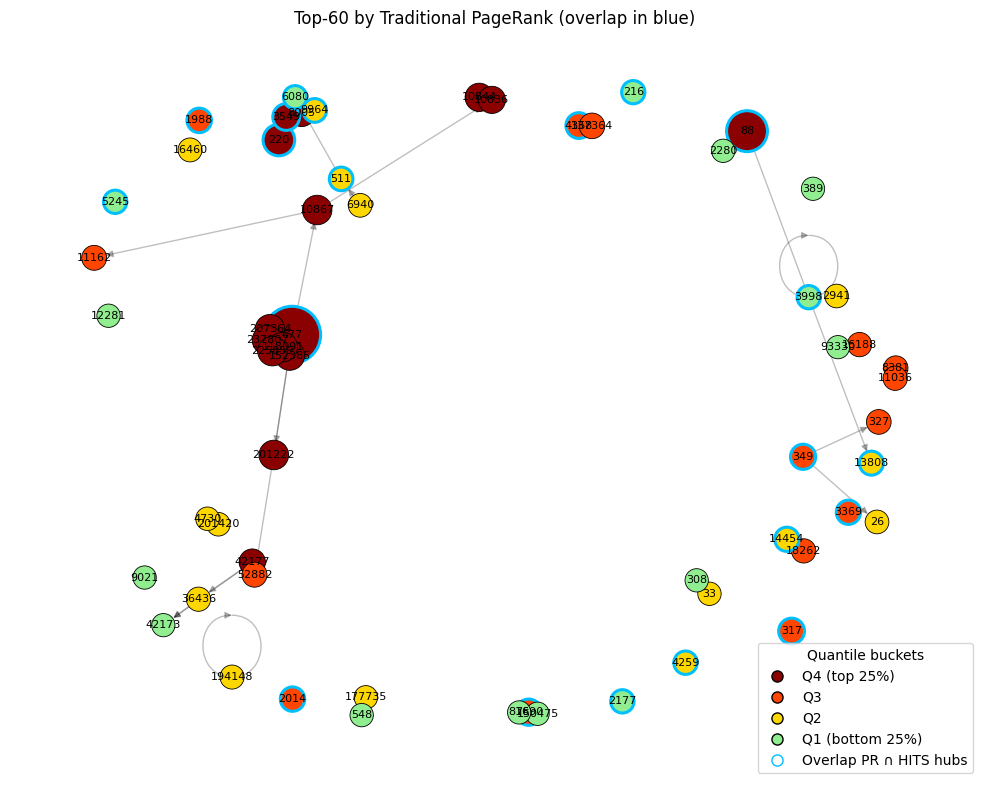

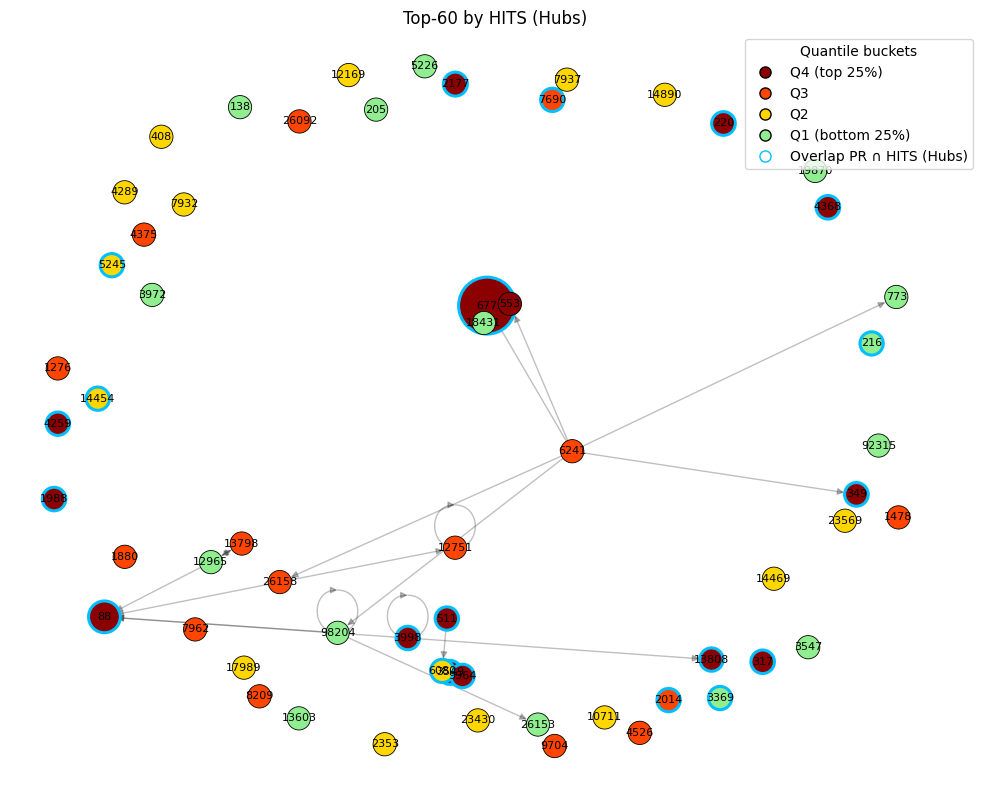

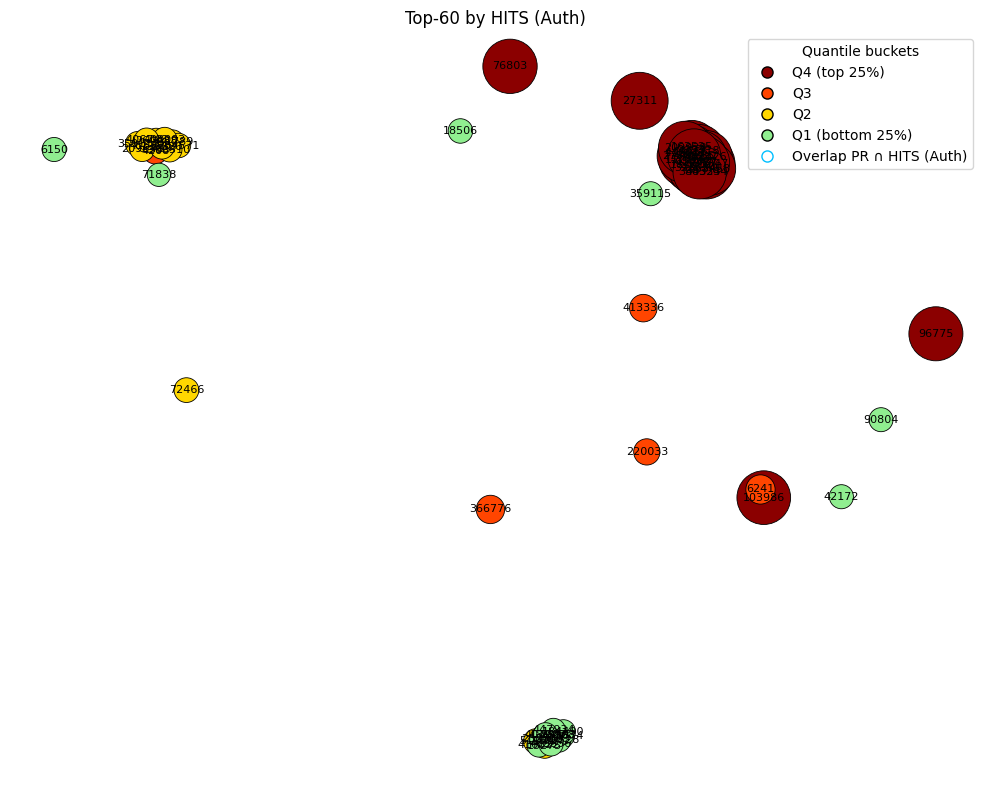

In [76]:
def _top_nodes(score_dict, n=60):
    return [u for u, _ in sorted(score_dict.items(), key=lambda kv: kv[1], reverse=True)[:n]]

def _quantile_bucket_fn(scores, nodes, qs=(0.75, 0.5, 0.25)):
    vals = np.array([scores[n] for n in nodes], dtype=float)
    qhi, qmid, qlow = np.quantile(vals, qs)
    def bucket(n):
        v = scores[n]
        if v >= qhi:  return "Q4 (top 25%)"
        if v >= qmid: return "Q3"
        if v >= qlow: return "Q2"
        return "Q1 (bottom 25%)"
    legend = {
        "Q4 (top 25%)": "darkred",
        "Q3": "orangered",
        "Q2": "gold",
        "Q1 (bottom 25%)": "lightgreen",
    }
    return bucket, legend

def plot_scored_subgraph(
    G: nx.DiGraph,
    scores: dict,
    top_n: int = 60,
    title: str = "",
    use_quantile_buckets: bool = True,
    fixed_thresholds=(0.1, 0.04, 0.01, 0.0),
    seed_layout: int = 42,
    pos: dict | None = None,
    highlight: set | None = None,          # <--- NEW
):
    # pick nodes
    nodes = _top_nodes(scores, n=top_n)
    H = G.subgraph(nodes).copy()

    # bucket + colors
    if use_quantile_buckets:
        bucket, legend = _quantile_bucket_fn(scores, nodes)
    else:
        # fixed thresholds version if you want it
        th = fixed_thresholds
        def bucket(n):
            v = scores[n]
            if v > th[0]: return f">{th[0]}"
            if v > th[1]: return f">{th[1]}"
            if v > th[2]: return f">{th[2]}"
            if v > th[3]: return f">{th[3]}"
            return "≤0"
        legend = {
            f">{th[0]}": "darkred",
            f">{th[1]}": "orangered",
            f">{th[2]}": "gold",
            f">{th[3]}": "lightgreen",
            "≤0": "lightgray",
        }

    color_map = {n: legend[bucket(n)] for n in nodes}

    # sizes ~ normalized score (within this subgraph)
    vals = np.array([scores[n] for n in nodes], dtype=float)
    vmin, vmax = vals.min(), vals.max()
    norm = (vals - vmin) / (vmax - vmin + 1e-12)
    sizes = 280 + 1400 * norm

    # layout: reuse if provided (so plots are comparable)
    if pos is None:
        pos = nx.spring_layout(H, seed=seed_layout)

    # highlight edges/borders for overlap
    highlight = highlight or set()
    edgecols = ["deepskyblue" if n in highlight else "black" for n in nodes]
    lws = [2.2 if n in highlight else 0.6 for n in nodes]

    fig, ax = plt.subplots(figsize=(10, 8))
    nx.draw_networkx_edges(H, pos, alpha=0.25, arrows=True, ax=ax)
    nx.draw_networkx_nodes(
        H, pos,
        nodelist=nodes,
        node_color=[color_map[n] for n in nodes],
        node_size=sizes,
        edgecolors=edgecols, linewidths=lws,
        ax=ax
    )
    if H.number_of_nodes() <= 80:
        nx.draw_networkx_labels(H, pos, font_size=8, ax=ax)

    # legend
    handles = [plt.Line2D([0],[0], marker='o', color='w',
                          markerfacecolor=c, markeredgecolor='black',
                          markersize=8, label=lab)
               for lab, c in legend.items()]
    # add highlight legend entry
    if title.endswith("(overlap in blue)"):
        handles.append(plt.Line2D([0],[0], marker='o', color='w',
                              markerfacecolor='white', markeredgecolor='deepskyblue',
                              linewidth=2.2, markersize=8, label='Overlap PR ∩ HITS hubs'))
    else:
        handles.append(plt.Line2D([0],[0], marker='o', color='w',
                              markerfacecolor='white', markeredgecolor='deepskyblue',
                              linewidth=2.2, markersize=8, label=f'Overlap PR ∩ {title[-11:]}'))
    ax.legend(handles=handles, title=("Quantile buckets" if use_quantile_buckets else "Fixed buckets"))
    ax.set_title(title or "Top-N scored induced subgraph")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
# ---- compute metrics & make comparable plots with shared layout ----
pr = nx.pagerank(G, alpha=0.85)
auth, hubs = nx.hits(G, max_iter=1000, tol=1e-8, normalized=True)

top60_pr   = _top_nodes(pr,   n=60)
top60_auth = _top_nodes(auth, n=60)
top60_hubs = _top_nodes(hubs, n=60)

overlap = set(top60_pr).intersection(top60_hubs)

# shared layout over the union so positions are comparable
union_nodes = set(top60_pr) | set(top60_auth)
H_union = G.subgraph(union_nodes).copy()
pos_union = nx.spring_layout(H_union, seed=42)

# PR plot with highlighted overlap
plot_scored_subgraph(
    G, pr, top_n=60,
    title="Top-60 by Traditional PageRank (overlap in blue)",
    use_quantile_buckets=True,
    pos={n: pos_union[n] for n in set(top60_pr)},  # subset the union layout
    highlight=overlap
)

union_nodes = set(top60_pr) | set(top60_hubs)
H_union = G.subgraph(union_nodes).copy()
pos_union = nx.spring_layout(H_union, seed=42)
plot_scored_subgraph(
    G, hubs, top_n=60,
    title="Top-60 by HITS (Hubs)",
    use_quantile_buckets=True,
    pos={n: pos_union[n] for n in set(top60_hubs)},  # subset the union layout
    highlight=overlap
)

union_nodes = set(top60_pr) | set(top60_auth)
H_union = G.subgraph(union_nodes).copy()
pos_union = nx.spring_layout(H_union, seed=42)
plot_scored_subgraph(
    G, auth, top_n=60,
    title="Top-60 by HITS (Auth)",
    use_quantile_buckets=True,
    pos={n: pos_union[n] for n in set(top60_auth)},  # subset the union layout
    highlight=overlap
)

**PR vs HITS Hubs**\
(3998,88,13808) cluster in both\
667 in both, but its cluster is completely missing in HITS hubs, since it is the hub\
(511,6080,3545,9964) cluster in both\
many unconnected nodes repeated that evidently scored highly where their connections did not\
**HITS Auths**\
We see much larger and denser clusters of descending score\
No similar nodes to the previous graphs\
\
While PR is scored by a random surfer, HITS hub nodes get higher scores when they point to high-scoring auth nodes, and HITS auth nodes get higher scores when pointed to by high-scoring hub nodes. This means our clusters aren't actually necessarily connected, but nodes that are pointed at by similar high-ranking hubs.

### E) **Bow‑tie Decomposition** (web‑like graphs): Partition nodes into IN/SCC/OUT/tendrils and visualize proportions.

SCC           : 322
IN            : 2790
OUT           : 479
TUBES         : 53
IN_TENDRILS   : 863
OUT_TENDRILS  : 3453
OTHER         : 30958


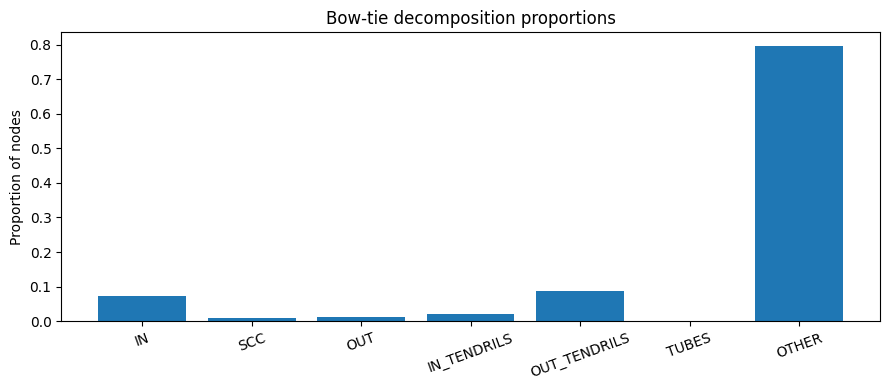

In [77]:
from collections import deque

def _multi_reach(G: nx.DiGraph, sources, reverse=False):
    """Nodes reachable from any source (reverse=True walks on reversed edges)."""
    if reverse:
        G = G.reverse(copy=False)
    seen = set(sources)
    dq = deque(sources)
    while dq:
        u = dq.popleft()
        for v in G[u]:
            if v not in seen:
                seen.add(v)
                dq.append(v)
    return seen

def bow_tie_partition(G: nx.DiGraph):
    """
    Partition nodes into IN / SCC / OUT / IN_TENDRILS / OUT_TENDRILS / TUBES / OTHER
    using the condensation DAG of SCCs (fast & robust).
    """
    # 1) SCCs and condensation DAG
    sccs = list(nx.strongly_connected_components(G))
    core_idx = max(range(len(sccs)), key=lambda i: len(sccs[i]))  # largest SCC = core
    C = nx.condensation(G, sccs)  # DAG of components; each node has attribute 'members' (set of original nodes)

    # 2) IN/OUT in the DAG (on SCC components)
    to_core   = _multi_reach(C, [core_idx], reverse=True)   # comps that can reach core (includes core)
    from_core = _multi_reach(C, [core_idx], reverse=False)  # comps reachable from core (includes core)

    IN_comps  = to_core   - {core_idx}
    OUT_comps = from_core - {core_idx}

    # 3) Tendrils & tubes in the DAG
    # From any IN component, go forward; from any OUT component, go backward.
    reach_from_IN  = _multi_reach(C, IN_comps, reverse=False) if IN_comps else set()
    reach_to_OUT   = _multi_reach(C, OUT_comps, reverse=True) if OUT_comps else set()

    # Exclude the bow-tie core sets
    excluded = IN_comps | OUT_comps | {core_idx}

    TUBE_comps       = (reach_from_IN & reach_to_OUT) - excluded
    IN_TEND_comps    = (reach_from_IN - reach_to_OUT) - excluded
    OUT_TEND_comps   = (reach_to_OUT - reach_from_IN) - excluded

    # Everything else
    ALL = set(C.nodes)
    OTHER_comps = ALL - (IN_comps | OUT_comps | {core_idx} | TUBE_comps | IN_TEND_comps | OUT_TEND_comps)

    # 4) Lift back to original nodes
    def comp_nodes(comp_ids):
        nodes = set()
        for cid in comp_ids:
            nodes |= set(C.nodes[cid]['members'])
        return nodes

    parts = {
        'SCC':          comp_nodes({core_idx}),
        'IN':           comp_nodes(IN_comps),
        'OUT':          comp_nodes(OUT_comps),
        'TUBES':        comp_nodes(TUBE_comps),
        'IN_TENDRILS':  comp_nodes(IN_TEND_comps),
        'OUT_TENDRILS': comp_nodes(OUT_TEND_comps),
        'OTHER':        comp_nodes(OTHER_comps),
    }
    return parts

def plot_bow_tie_proportions(parts: dict, kind: str = "bar"):
    """Visualize proportions of the bow-tie pieces."""
    labels = ['IN','SCC','OUT','IN_TENDRILS','OUT_TENDRILS','TUBES','OTHER']
    counts = [len(parts[k]) for k in labels]
    total = sum(counts)
    props = [c/total if total else 0 for c in counts]

    if kind == "bar":
        import numpy as np
        xs = np.arange(len(labels))
        plt.figure(figsize=(9,4))
        plt.bar(xs, props)
        plt.xticks(xs, labels, rotation=20)
        plt.ylabel("Proportion of nodes")
        plt.title("Bow-tie decomposition proportions")
        plt.tight_layout()
        plt.show()
    else:  # pie
        plt.figure(figsize=(6,6))
        plt.pie(props, labels=labels, autopct=lambda p: f"{p:.1f}%")
        plt.title("Bow-tie decomposition proportions")
        plt.tight_layout()
        plt.show()

parts = bow_tie_partition(G)
for k,v in parts.items():
    print(f"{k:14s}: {len(v)}")

plot_bow_tie_proportions(parts, kind="bar")

As I mentioned at the end of section 3, I expected many more interactions between our heavily connected nodes, but much of our data falls into the 'other' column. Again going back to our initial findings and constructing the webbed scc in fairly sparse data, this makes sense. Most of our connected nodes feed into the scc, then around our web nodes chain and tendril out. 

## 9. Reporting Checklist (What to Document) (5 pts)
Please note that this 5 pts are for documentation in general throughout your homework notebook.

As a guide, for each step of the homework, you should briefly document:
- **Method choice & rationale.** Why this method? What do you expect?
- **Parameters.** E.g., `alpha=0.85` for PageRank; seed selection for PPR; thresholds for community extraction.
- **Results.** Tables/plots + **1–3 sentences** of interpretation.
- **Reflection.** Did results match your expectations? If not, why might that be?

Ideally, strong submissions should read like a *short research memo* rather than a raw dump of numbers.


I expected the data to be denser around the largest node 677. This dataset is not the best representation for interaction since it reports minimal information that an account has replied to another account. This says nothing of like or retweet or even the contents of the message, but that a user went out of their way to write to another user after seeing what they had posted

## 10. Citation
Please cite SNAP appropriately (see each dataset page). Example:

> Jure Leskovec and Andrej Krevl. SNAP Datasets: Stanford Large Network Dataset Collection. http://snap.stanford.edu/data.

If you used specific papers (PageRank, HITS, PPR, LSH/MinHash), you could also add those citations, too.


- J. Leskovec, & A. Krevl, (2014). *SNAP Datasets: Stanford Large Network Dataset Collection*. Retrieved from [http://snap.stanford.edu/data](http://snap.stanford.edu/data)

- M. De Domenico, A. Lima, & M. Musolesi, (2013). *The Anatomy of a Scientific Rumor*. Scientific Reports 3, 2980. [https://doi.org/10.1038/srep02980](https://doi.org/10.1038/srep02980)